In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [15]:
df = pd.read_csv('fetal_health.csv')
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

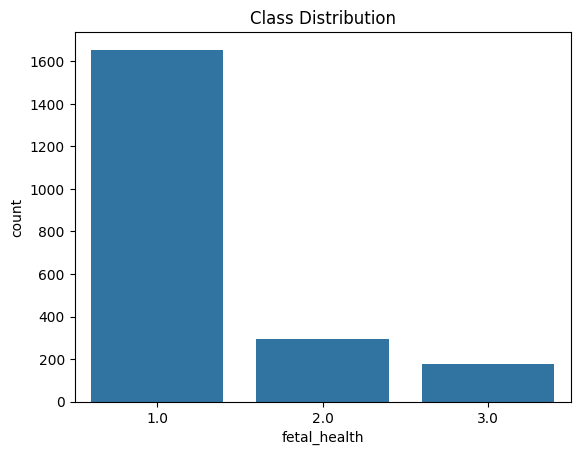

In [17]:
df.info()
print(df.isnull().sum())
df.describe()
sns.countplot(x='fetal_health', data=df)
plt.title('Class Distribution')
plt.show()


In [18]:
X = df[[
    'baseline value',
    'accelerations',
    'fetal_movement',
    'uterine_contractions',
    'light_decelerations',
    'severe_decelerations'
]]
y = df['fetal_health'] - 1
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1700, 6)
X_test shape: (426, 6)


In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: 1.0, 1: 2.0, 2: 2.5}
print("Class weights:", class_weight_dict)

Class weights: {0: 1.0, 1: 2.0, 2: 2.5}


In [20]:
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])
ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,627 (10.26 KB)

 Trainable params: 2,627 (10.26 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = ann_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )
    ],
    verbose=1
)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.6390 - loss: 1.2619 - val_accuracy: 0.8000 - val_loss: 0.7854 - learning_rate: 0.0010
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7772 - loss: 1.0438 - val_accuracy: 0.7941 - val_loss: 0.6414 - learning_rate: 0.0010
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7963 - loss: 0.9322 - val_accuracy: 0.8235 - val_loss: 0.5553 - learning_rate: 0.0010
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8037 - loss: 0.8604 - val_accuracy: 0.8088 - val_loss: 0.5226 - learning_rate: 0.0010
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8000 - loss: 0.8043 - val_accuracy: 0.8206 - val_loss: 0.4964 - learning_rate: 0.0010
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7956 - loss: 0.7832 - val_accuracy: 0.8265 - val_loss: 0.4856 - learning_rate: 0.0010
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7868 - loss: 0.7867 - val_accuracy:

In [22]:
y_pred_prob = ann_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)
print("Accuracy:", accuracy_score(y_test_labels, y_pred))
print("Macro F1 Score:", f1_score(y_test_labels, y_pred, average="macro"))
print("Weighted F1 Score:", f1_score(y_test_labels, y_pred, average="weighted"))
print("\nClassification Report:\n")
print(classification_report(
    y_test_labels,
    y_pred,
    target_names=["Normal", "Suspect", "Pathological"],
    digits=4
))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Accuracy: 0.7981220657276995
Macro F1 Score: 0.629517375629754
Weighted F1 Score: 0.8094667374523355

Classification Report:

              precision    recall  f1-score   support

      Normal     0.9398    0.8464    0.8906       332
     Suspect     0.4839    0.7627    0.5921        59
Pathological     0.4118    0.4000    0.4058        35

    accuracy                         0.7981       426
   macro avg     0.6118    0.6697    0.6295       426
weighted avg     0.8333    0.7981    0.8095       426



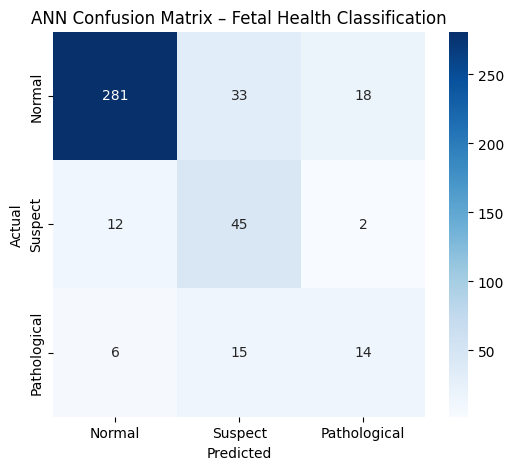

In [23]:
cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Suspect", "Pathological"],
    yticklabels=["Normal", "Suspect", "Pathological"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix – Fetal Health Classification")
plt.show()

In [24]:
ann_model.save("fetal_health_ann_model.h5")

In [25]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Training Accuracy: 0.8007352948188782
Validation Accuracy: 0.7764706015586853


In [26]:
ann_model.save("ann_fhr_model.keras")

In [27]:
from google.colab import files
files.download("ann_fhr_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import tensorflow as tf
model = tf.keras.models.load_model("ann_fhr_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [29]:
import joblib
joblib.dump(scaler, "fhr_scaler.pkl")

['fhr_scaler.pkl']

In [30]:
from google.colab import files
files.download("fhr_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import numpy as np
sample = np.array([[
    120, 0.85, 0.30, 2.1,
    3.4, 1.2
]])
sample_scaled = scaler.transform(sample)
pred_prob = model.predict(sample_scaled)
pred_class = np.argmax(pred_prob, axis=1)
print("Prediction probabilities:", pred_prob)
print("Predicted class:", pred_class)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
Prediction probabilities: [[0. 0. 1.]]
Predicted class: [2]


In [32]:
sample_scaled = scaler.transform(sample)
pred_prob = model.predict(sample_scaled)
pred_class = np.argmax(pred_prob, axis=1)
label_map = {0: "Normal", 1: "Suspect", 2: "Pathological"}
print("Prediction:", label_map[pred_class[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediction: Pathological


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [33]:
ann_model.save("fetal_health_ann_model.h5")